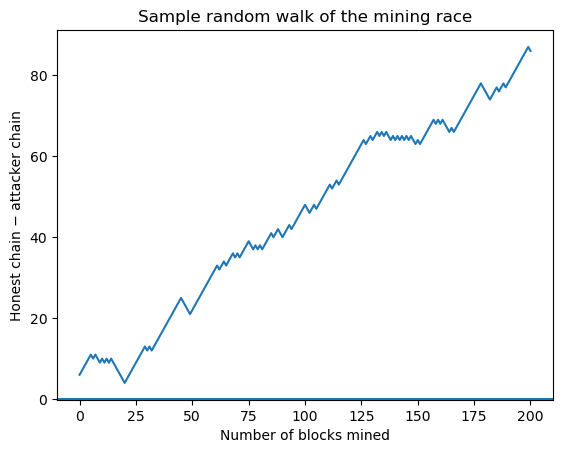

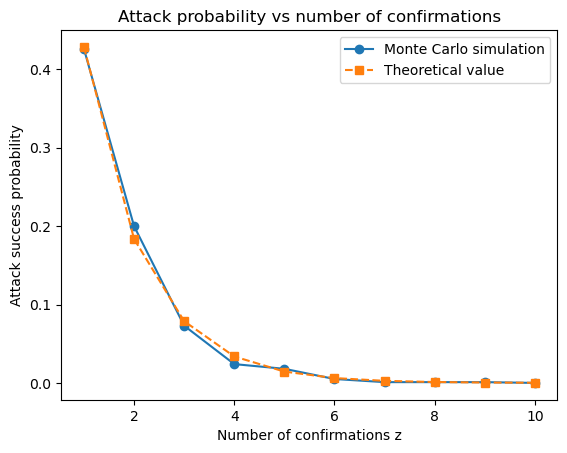

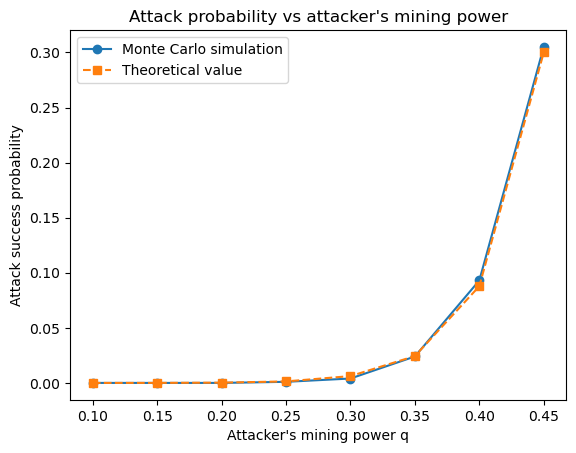

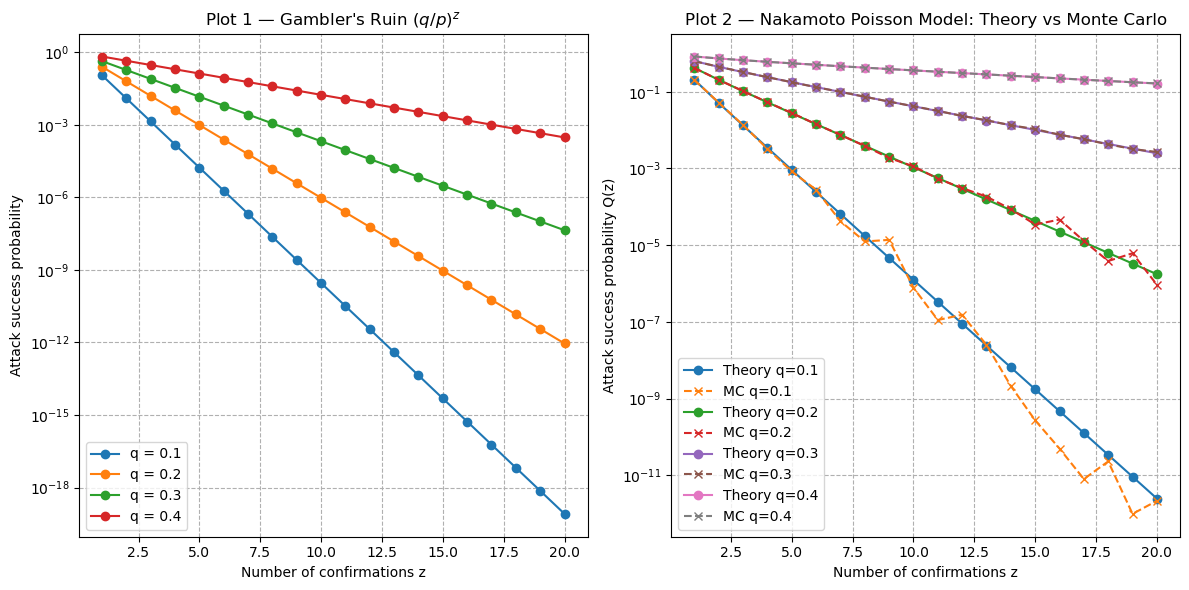

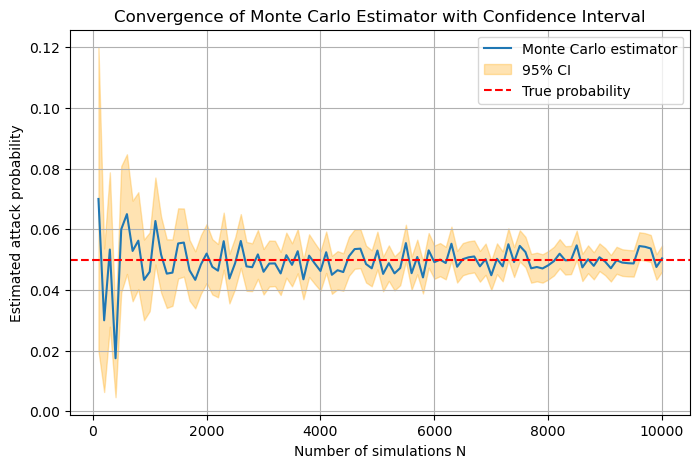

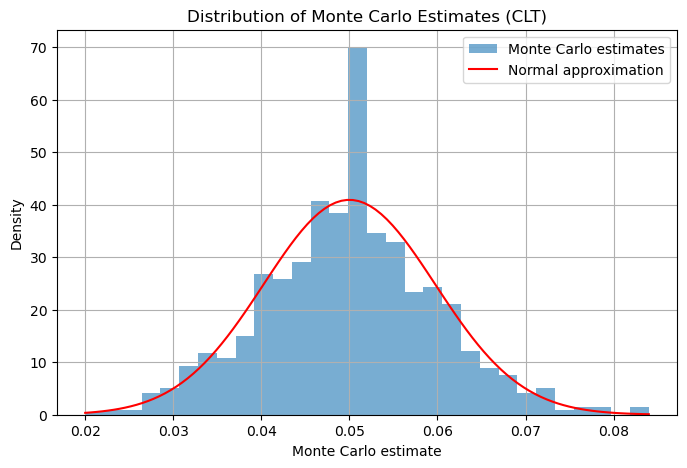

In [ ]:

#  ==========================================
# Monte Carlo simulation of blockchain mining
# ==========================================

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# --------- Core Monte Carlo functions ---------

def simulate_one_attack(p, q, z, max_steps=1000):
    X = z
    for _ in range(max_steps):
        r = random.random()
        if r < p:
            X += 1
        else:
            X -= 1
        if X == 0:
            return True
    return False


def monte_carlo_attack_probability(p, q, z, N=1000):
    successes = 0
    for _ in range(N):
        if simulate_one_attack(p, q, z):
            successes += 1
    return successes / N


def simulate_random_walk_path(p, q, z, max_steps=200):
    X = z
    path = [X]
    for _ in range(max_steps):
        r = random.random()
        if r < p:
            X += 1
        else:
            X -= 1
        path.append(X)
        if X == 0:
            break
    return path

# --------- Simulation 1: random walk trajectory ---------

p = 0.7
q = 0.3
z = 6

path = simulate_random_walk_path(p, q, z)


plt.figure()
plt.plot(path)
plt.axhline(0)
plt.xlabel("Number of blocks mined")
plt.ylabel("Honest chain − attacker chain")
plt.title("Sample random walk of the mining race")
plt.show()

# --------- Simulation 2: attack probability vs confirmations ---------

z_values = range(1, 11)
simulated_probs = []
theoretical_probs = []

for z in z_values:
    simulated_probs.append(monte_carlo_attack_probability(p, q, z))
    theoretical_probs.append((q / p) ** z)



plt.figure()
plt.plot(z_values, simulated_probs, marker='o', label="Monte Carlo simulation")
plt.plot(z_values, theoretical_probs, marker='s', linestyle='--', label="Theoretical value")
plt.xlabel("Number of confirmations z")
plt.ylabel("Attack success probability")
plt.title("Attack probability vs number of confirmations")
plt.legend()
plt.show()

# --------- Simulation 3: attack probability vs mining power ---------

q_values = np.linspace(0.1, 0.45, 8)
z = 6
simulated_probs = []
theoretical_probs = []

for q in q_values:
    p = 1 - q
    simulated_probs.append(monte_carlo_attack_probability(p, q, z))
    theoretical_probs.append((q / p) ** z)

plt.figure()
plt.plot(q_values, simulated_probs, marker='o', label="Monte Carlo simulation")
plt.plot(q_values, theoretical_probs, marker='s', linestyle='--', label="Theoretical value")
plt.xlabel("Attacker's mining power q")
plt.ylabel("Attack success probability")
plt.title("Attack probability vs attacker's mining power")
plt.legend()
plt.show()











# Paramètres
qs = [0.1, 0.2, 0.3, 0.4]  # fractions de l'attaquant
z_max = 20
z_vals = np.arange(1, z_max + 1)
n_sim = 100000  # nombre de simulations Monte Carlo

# --------------------------
# Gambler's Ruin (q/p)^z
# --------------------------
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
for q in qs:
    p = 1 - q
    P_success = (q / p) ** z_vals
    plt.plot(z_vals, P_success, marker='o', label=f'q = {q}')

plt.yscale('log')
plt.xlabel('Number of confirmations z')
plt.ylabel('Attack success probability')
plt.title("Plot 1 — Gambler's Ruin $(q/p)^z$")
plt.grid(True, which="both", ls="--")
plt.legend()

# --------------------------
# Nakamoto Poisson Model + Monte Carlo
# --------------------------
plt.subplot(1,2,2)
for q in qs:
    p = 1 - q
    # Théorie Poisson
    Q_theory = []
    for z in z_vals:
        lam = z * (q / p)
        k_max = 50  # tronque la somme pour performance
        k = np.arange(0, k_max+1)
        poisson_prob = poisson.pmf(k, lam)
        Q_k = np.where(k >= z, 1.0, (q/p)**(z - k))
        Q_theory.append(np.sum(poisson_prob * Q_k))
    
    # Simulation Monte Carlo
    Q_sim = []
    for z in z_vals:
        lam = z * (q / p)
        K = np.random.poisson(lam, n_sim)
        # Calculer succès conditionnel
        success = np.where(K >= z, 1.0, (q/p)**(z - K))
        Q_sim.append(np.mean(success))
    
    plt.plot(z_vals, Q_theory, marker='o', label=f'Theory q={q}')
    plt.plot(z_vals, Q_sim, marker='x', linestyle='--', label=f'MC q={q}')

plt.yscale('log')
plt.xlabel('Number of confirmations z')
plt.ylabel('Attack success probability Q(z)')
plt.title("Plot 2 — Nakamoto Poisson Model: Theory vs Monte Carlo")
plt.grid(True, which="both", ls="--")
plt.legend()

plt.tight_layout()
plt.show()







# --------------------------
# Monte Carlo Simulations (convergence )
# --------------------------




N_values = np.arange(100, 10001, 100)
true_prob = 0.05  # example
estimates = []

for N in N_values:
    sim_results = np.random.binomial(1, true_prob, N)
    P_hat = sim_results.mean()
    estimates.append(P_hat)

estimates = np.array(estimates)
CI_upper = estimates + 1.96*np.sqrt(estimates*(1-estimates)/N_values)
CI_lower = estimates - 1.96*np.sqrt(estimates*(1-estimates)/N_values)

plt.figure(figsize=(8,5))
plt.plot(N_values, estimates, label='Monte Carlo estimator')
plt.fill_between(N_values, CI_lower, CI_upper, color='orange', alpha=0.3, label='95% CI')
plt.axhline(true_prob, color='red', linestyle='--', label='True probability')
plt.xlabel('Number of simulations N')
plt.ylabel('Estimated attack probability')
plt.title('Convergence of Monte Carlo Estimator with Confidence Interval')
plt.legend()
plt.grid(True)
plt.show()

simulations = 1000
N = 500
P_samples = [np.random.binomial(N, true_prob)/N for _ in range(simulations)]

plt.figure(figsize=(8,5))
plt.hist(P_samples, bins=30, density=True, alpha=0.6, label='Monte Carlo estimates')

# Normal approximation
mu = true_prob
sigma = np.sqrt(true_prob*(1-true_prob)/N)
x = np.linspace(min(P_samples), max(P_samples), 100)
plt.plot(x, 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sigma**2)), color='red', label='Normal approximation')
plt.xlabel('Monte Carlo estimate')
plt.ylabel('Density')
plt.title('Distribution of Monte Carlo Estimates (CLT)')
plt.legend()
plt.grid(True)
plt.show()


